In [2]:
import numpy as np
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sns 
import statistics as sts 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier


In [3]:
X,y=make_classification(n_samples=10000,n_features=18,n_informative=4,n_redundant=12,random_state=42)


In [4]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3)

In [5]:
train_score, test_score=list(),list()

In [6]:
values=[i for i in range(1,21)]

In [7]:
for i in values:
    model=DecisionTreeClassifier(max_depth=i)
    model.fit(x_train,y_train)
    train_yhat=model.predict(x_train)
    train_acc=accuracy_score(y_train,train_yhat)
    test_yhat=model.predict(x_test)
    test_acc=accuracy_score(y_test,test_yhat)
    train_score.append(train_acc)
    test_score.append(test_acc)
    print('>%d, train : %.3f, test: %.3f'% (i,train_acc,test_acc))
    

>1, train : 0.736, test: 0.723
>2, train : 0.794, test: 0.795
>3, train : 0.861, test: 0.852
>4, train : 0.904, test: 0.895
>5, train : 0.928, test: 0.913
>6, train : 0.935, test: 0.917
>7, train : 0.946, test: 0.915
>8, train : 0.956, test: 0.910
>9, train : 0.967, test: 0.916
>10, train : 0.975, test: 0.910
>11, train : 0.980, test: 0.909
>12, train : 0.985, test: 0.912
>13, train : 0.989, test: 0.906
>14, train : 0.992, test: 0.908
>15, train : 0.995, test: 0.901
>16, train : 0.996, test: 0.902
>17, train : 0.997, test: 0.899
>18, train : 0.999, test: 0.896
>19, train : 0.999, test: 0.898
>20, train : 1.000, test: 0.898


[0.7361428571428571, 0.794, 0.861, 0.9037142857142857, 0.9277142857142857, 0.9347142857142857, 0.946, 0.9557142857142857, 0.9668571428571429, 0.9747142857142858, 0.9804285714285714, 0.985, 0.989, 0.9921428571428571, 0.9947142857142857, 0.9964285714285714, 0.9971428571428571, 0.9988571428571429, 0.999, 0.9997142857142857]
[0.7233333333333334, 0.7946666666666666, 0.8516666666666667, 0.895, 0.913, 0.917, 0.9153333333333333, 0.9096666666666666, 0.9163333333333333, 0.9096666666666666, 0.9086666666666666, 0.912, 0.906, 0.908, 0.901, 0.9023333333333333, 0.899, 0.8963333333333333, 0.8976666666666666, 0.8976666666666666]


<Axes: ylabel='Density'>

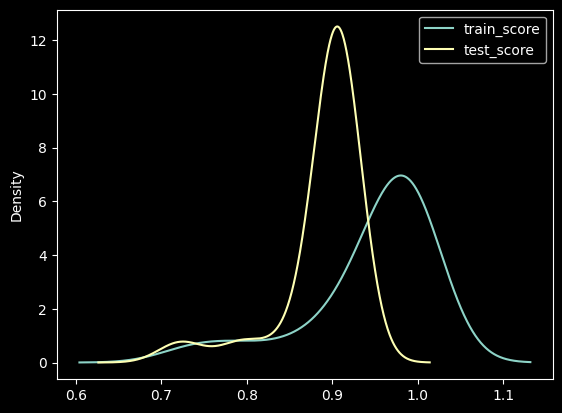

In [8]:
print(train_score)
print(test_score)

cl1=['#ff4d01','#ffffff']
data={
    "train_score": train_score,
    "test_score":test_score,
    "y_values":values
}

dataframe=pd.DataFrame(data=data,columns=['train_score',"test_score"])


dataframe[['train_score','test_score']].plot(kind='kde')


In [9]:
from sklearn.model_selection import GridSearchCV
# to reduce the overfittiing problem
param_grid={'criterion':['gini','entropy'],'max_depth':[2,4,6,8,10,20],'min_samples_split':[5,10,20,30,50,100,200]}
clf=GridSearchCV(DecisionTreeClassifier(),param_grid,cv=3,n_jobs=-1,scoring="accuracy")
clf.fit(x_train,y_train)


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'min_samples_split': [5, 10, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [10]:
clf.best_estimator_
clf.best_score_

np.float64(0.9187147925282018)

In [11]:
print(accuracy_score(y_train,clf.best_estimator_.predict(x_train)))
print(accuracy_score(y_test,clf.best_estimator_.predict(x_test)))

0.9541428571428572
0.9106666666666666


#under fitting increase the models
#overfitting problems decrease the features and or 



When to Use GridSearchCV and cross_val_score:
GridSearchCV:
Purpose: Helps you find the best settings (hyperparameters) for your model.
Use Case: When you want to make your model as good as possible by trying different combinations of settings.
cross_val_score:
Purpose: Tells you how well your model performs on average when tested on different parts of your data.
Use Case: When you want to check if your model is reliable and not just lucky with one set of data.


Cross-Validation Scores: [0.86 0.92 0.88 0.94 0.9]
Average Accuracy: 0.9

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Create sample data
X, y = make_classification(n_samples=100, n_features=5)

# Define parameter grid
param_grid = {
    'n_estimators': [10, 50, 100],  # Number of trees in the forest
    'max_depth': [None, 5, 10]      # Maximum depth of each tree
}

# Perform Grid Search with 5-fold CV
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_search.fit(X, y)

# Output
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 10}
Best Score: 0.89


In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Create sample data
X, y = make_classification(n_samples=100000, n_features=5)

# Model
model = RandomForestClassifier()

# Perform 5-fold cross-validation
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

# Output
print("Cross-Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross-Validation Scores: [0.97015 0.96745 0.96725 0.9703  0.9664 ]
Average Accuracy: 0.96831


In [1]:
import numpy as np
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sns 
import statistics as sts 

In [5]:
x=np.random.randint(low=0,high=10000,size=10000)
y=np.random.randint(low=0,high=10000,size=10000)

In [6]:
data={
    "col1":x,
    "col2":y
}

df1=pd.DataFrame(data=data,columns=['col1','col2'])
df1.sample(10)


,col1,col2
5828,4548,4578
9641,2718,8648
9350,1351,4004
3562,1787,379
8011,8840,4030
4071,7237,5964
9729,4182,1130
8720,3002,9011
7132,1767,438
857,9018,1204


In [20]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   col1    10000 non-null  int32
 1   col2    10000 non-null  int32
dtypes: int32(2)
memory usage: 78.3 KB


In [56]:
d1={
    'x':[1,2,3,4,5,6,10,90,80,100],
    'y':[100,200,290,1,390,900,1900,1800,12000,12000]
    
}

df2=pd.DataFrame(data=d1,columns=['x','y'])


In [64]:
class RobustAnomalyDetection:
    def __init__(self, data):
        self.data = data

    def detect_anomalies(self, column):
        q1 = self.data[column].quantile(0.25)
        q3 = self.data[column].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return (self.data[column] < lower) | (self.data[column] > upper)

# Usage
numeric_data = df2.select_dtypes(include='number')
detector = RobustAnomalyDetection(numeric_data)

masked_df=df2.copy()
for col in numeric_data.columns:
    mask = detector.detect_anomalies(col)
    if mask.any():
        print(f"{col}: anomalies present")
        print(df2[mask])
        print("dropping the indexes elememenst is removing the indexes")
        anomolies_index=df2[mask].index
        masked_df=masked_df.drop(index=anomolies_index)
        print(len(anomolies_index))
    else:
        print(f"{col}: no anomalies present")

x: no anomalies present
y: anomalies present
     x      y
8   80  12000
9  100  12000
dropping the indexes elememenst is removing the indexes
2
